In [6]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

In [12]:
predictions = pd.read_csv("demo_geographic_landslide_predictions.csv")

print("Number of predictions:", len(predictions))
display(predictions.head())

Number of predictions: 12


,Demo_ID,State,Latitude,Longitude,Temperature (°C),Humidity (%),Precipitation (mm),Soil Moisture (%),Elevation (m),Predicted_Risk,Risk_Probability,Risk_Color
0,Demo-01,Assam,26.1445,91.7362,31,78,185,72,120,Very High,0.91,Red
1,Demo-02,Assam,27.4728,94.9120,24,70,142,61,280,High,0.78,Orange
2,Demo-03,Arunachal Pradesh,27.0844,93.6053,19,88,230,82,1450,Very High,0.95,Red
3,Demo-04,Arunachal Pradesh,28.2180,94.7278,17,82,190,75,980,High,0.84,Orange
4,Demo-05,Nagaland,25.6751,94.1086,22,76,155,64,620,Moderate,0.62,Yellow


In [13]:
ner = gpd.read_file("Northeast_India.geojson")

print(ner.columns)
print("Number of states:", len(ner))

display(ner)

Index(['state', 'geometry'], dtype='str')
Number of states: 8


,state,geometry
0,Assam,"POLYGON ((89.6 24.8, 96 24.8, 96 28.2, 95 28.3..."
1,Arunachal Pradesh,"POLYGON ((91.5 27.5, 96.2 27.4, 97 29.6, 96 30..."
2,Nagaland,"POLYGON ((93.3 25, 95.3 25, 95.5 27.1, 94.2 27..."
3,Manipur,"POLYGON ((93 23.8, 94.8 24, 94.6 25.7, 93.5 25..."
4,Mizoram,"POLYGON ((92.1 21.9, 93.2 22, 93.4 24.4, 92.5 ..."
5,Tripura,"POLYGON ((91 22.9, 92.1 22.7, 92.3 24.5, 91.6 ..."
6,Meghalaya,"POLYGON ((89.7 25, 92.8 25, 92.7 26.3, 90.1 26..."
7,Sikkim,"POLYGON ((88 27.1, 88.9 27.1, 89 28.2, 88.3 28..."


In [14]:
prediction_points = gpd.GeoDataFrame(
    predictions,
    geometry=gpd.points_from_xy(
        predictions["Longitude"],
        predictions["Latitude"]
    ),
    crs="EPSG:4326"
)

display(prediction_points)

,Demo_ID,State,Latitude,Longitude,Temperature (°C),Humidity (%),Precipitation (mm),Soil Moisture (%),Elevation (m),Predicted_Risk,Risk_Probability,Risk_Color,geometry
0,Demo-01,Assam,26.1445,91.7362,31,78,185,72,120,Very High,0.91,Red,POINT (91.7362 26.1445)
1,Demo-02,Assam,27.4728,94.9120,24,70,142,61,280,High,0.78,Orange,POINT (94.912 27.4728)
2,Demo-03,Arunachal Pradesh,27.0844,93.6053,19,88,230,82,1450,Very High,0.95,Red,POINT (93.6053 27.0844)
3,Demo-04,Arunachal Pradesh,28.2180,94.7278,17,82,190,75,980,High,0.84,Orange,POINT (94.7278 28.218)
4,Demo-05,Nagaland,25.6751,94.1086,22,76,155,64,620,Moderate,0.62,Yellow,POINT (94.1086 25.6751)
5,Demo-06,Manipur,24.8170,93.9368,23,80,175,69,790,High,0.81,Orange,POINT (93.9368 24.817)
6,Demo-07,Mizoram,23.7271,92.7176,21,85,210,78,680,Very High,0.93,Red,POINT (92.7176 23.7271)
7,Demo-08,Tripura,23.8315,91.2868,26,72,95,51,210,Moderate,0.55,Yellow,POINT (91.2868 23.8315)
8,Demo-09,Meghalaya,25.5788,91.8933,20,89,240,84,1100,Very High,0.96,Red,POINT (91.8933 25.5788)
9,Demo-10,Meghalaya,25.4670,90.2245,25,79,160,66,520,High,0.76,Orange,POINT (90.2245 25.467)


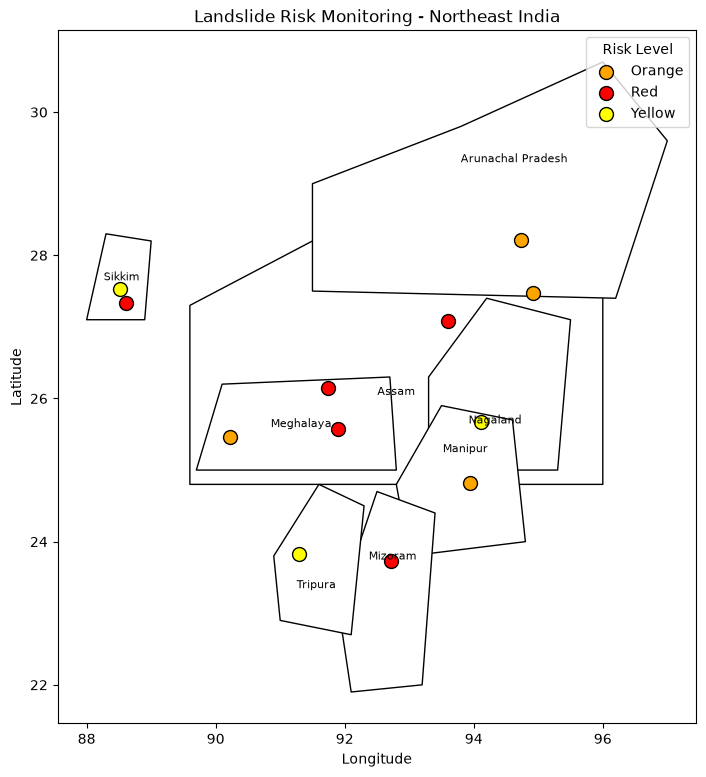

In [16]:
fig, ax = plt.subplots(figsize=(12, 9))

# Plot NER states
ner.plot(
    ax=ax,
    facecolor="white",
    edgecolor="black"
)

# Add state names
for _, row in ner.iterrows():
    point = row.geometry.representative_point()

    ax.text(
        point.x,
        point.y,
        row["state"],
        fontsize=8,
        ha="center"
    )

# Risk colors
color_map = {
    "Green": "green",
    "Yellow": "yellow",
    "Orange": "orange",
    "Red": "red"
}

for risk_color, group in prediction_points.groupby("Risk_Color"):
    group.plot(
        ax=ax,
        color=color_map[risk_color],
        markersize=100,
        edgecolor="black",
        label=risk_color
    )

ax.set_title("Landslide Risk Monitoring - Northeast India")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.legend(title="Risk Level")

plt.show()

In [17]:
prediction_points.to_file(
    "landslide_risk_demo.geojson",
    driver="GeoJSON"
)

print("GIS prediction file created successfully!")

GIS prediction file created successfully!
